# Unit 5 — 03: Alerting and Incident Management for ML Models

**What you will do:** Build an `AlertManager` class that checks four conditions, generate synthetic logs with injected faults, run the manager, and walk through an incident response runbook.

**Why it matters:** Without alerts, you discover outages when users complain — hours after the fact. Automated alerting is the difference between a 5-minute response and a 5-hour outage.

**How to run:** Python 3.10+. Run cells in order.

## 🔗 Where this fits

**Builds on:** Course 06 (AIAT 116) — Unit 4, lesson 04 "04. Accountability Frameworks" — an alert with no named owner and no documented response path is not accountability; the runbook here is where those RACI roles and audit trails turn into an on-call procedure.

---

## 📰 4 October 2021: Facebook's runbook was behind the outage

During routine maintenance, a Meta engineer issued a command intended to assess available backbone capacity. It took the entire backbone down. An audit tool that should have blocked the command had a bug and did not. Then the failure cascaded in a way that is directly relevant to this notebook: Meta's DNS servers **withdraw their own BGP route advertisements when they cannot reach the data centres** — a deliberate safety behaviour — so the moment the backbone dropped, Facebook's DNS servers removed themselves from the internet. They were still running. Nobody could find them.

The part that turns this from an outage into a lesson about incident management is what happened next. In Meta's own account, *"the total loss of DNS broke many of the internal tools we'd normally use to investigate and resolve outages."* Engineers had to be sent physically to data centres, and the high-security physical access controls — designed to be hard to bypass — slowed the repair further. The runbook depended on the systems the runbook was written to repair.

**What goes wrong without this lesson.** Without alerting you learn about incidents from users, hours late. But an alert that nobody owns, with no documented first steps, is barely better: the on-call engineer spends the first twenty minutes deciding what to look at. And a runbook whose steps all require the broken system is a document, not a plan.

## Section 1 — What Triggers an Alert

Four standard alert conditions for production ML services:

| Condition | Threshold | Implication |
|---|---|---|
| **Error rate** | > 1% of requests | Model or input validation is broken |
| **p99 latency** | > 500 ms | Model is too slow for SLO |
| **Prediction confidence** | < 0.6 average | Model is uncertain — likely distribution shift |
| **Dead service** | Zero predictions in last 5 min | Service has crashed or is not receiving traffic |

These thresholds are starting points. Real systems tune them based on observed baseline behavior.

## Section 2 — AlertManager Class

In [1]:
# Build the AlertManager: four independent checks (error rate, p99 latency,
# mean confidence, service liveness), each returning an alert string when its
# threshold is breached, or None when the metric is healthy.
import numpy as np
from typing import List, Dict, Optional
from datetime import datetime, timedelta, timezone


# Each check_* method owns one metric and one threshold — small, testable, composable.
class AlertManager:
    """Checks production logs against alert thresholds."""

    # Check 1: fraction of failed requests vs a 1% budget.
    def check_error_rate(
        self, logs: List[Dict], threshold: float = 0.01
    ) -> Optional[str]:
        """Alert if error rate exceeds threshold (default 1%)."""
        if not logs:
            return None
        n_errors = sum(1 for r in logs if r.get("error", False))
        rate = n_errors / len(logs)
        if rate > threshold:
            return (
                f"ALERT [error_rate]: {rate:.2%} > threshold {threshold:.2%} "
                f"({n_errors}/{len(logs)} errors)"
            )
        return None

    # Check 2: p99 latency of SUCCESSFUL requests vs the SLO.
    def check_latency(
        self, logs: List[Dict], p99_threshold_ms: float = 500.0
    ) -> Optional[str]:
        """Alert if p99 latency exceeds threshold."""
        latencies = [r["latency_ms"] for r in logs if not r.get("error", False)]
        if not latencies:
            return None
        p99 = float(np.percentile(latencies, 99))
        if p99 > p99_threshold_ms:
            return (
                f"ALERT [latency_p99]: {p99:.1f}ms > threshold {p99_threshold_ms:.1f}ms"
            )
        return None

    # Check 3: mean model confidence — an early quality signal without labels.
    def check_confidence(
        self, logs: List[Dict], threshold: float = 0.6
    ) -> Optional[str]:
        """Alert if mean prediction confidence drops below threshold."""
        confidences = [
            r["confidence"] for r in logs
            if not r.get("error", False) and "confidence" in r
        ]
        if not confidences:
            return None
        mean_conf = float(np.mean(confidences))
        if mean_conf < threshold:
            return (
                f"ALERT [confidence]: mean={mean_conf:.3f} < threshold {threshold:.3f}"
            )
        return None

    # Check 4: liveness — has ANYTHING succeeded recently?
    def check_service_alive(
        self, logs: List[Dict], window_minutes: float = 5.0,
        now: Optional[datetime] = None,
    ) -> Optional[str]:
        """Alert if no successful prediction within window_minutes of `now`.

        `now` defaults to the newest timestamp in the log slice, so reviewing a
        HISTORICAL batch of logs asks "was the service alive at the end of that
        window?" — old-but-healthy logs must not trip the alarm. For LIVE
        monitoring, pass now=datetime.now(timezone.utc) to compare against the
        wall clock instead (demonstrated in Section 4).
        """
        if not logs:
            return (
                f"ALERT [dead_service]: No successful predictions in last {window_minutes:.0f} minutes."
            )
        if now is None:
            # Anchor the window to the newest log entry being examined
            now = max(datetime.fromisoformat(r["timestamp"]) for r in logs)
        cutoff = now - timedelta(minutes=window_minutes)
        recent = [
            r for r in logs
            if not r.get("error", False)
            and datetime.fromisoformat(r["timestamp"]) > cutoff
        ]
        if not recent:
            return (
                f"ALERT [dead_service]: No successful predictions in last {window_minutes:.0f} minutes."
            )
        return None

    # Run every check and collect whatever fired into one list.
    def run_all_checks(
        self, logs: List[Dict], now: Optional[datetime] = None
    ) -> List[str]:
        """Run all checks and return a list of triggered alerts.

        `now` is forwarded to check_service_alive (None = anchor the liveness
        window to the newest log timestamp)."""
        alerts = []
        for check_fn in [
            self.check_error_rate,
            self.check_latency,
            self.check_confidence,
            lambda l: self.check_service_alive(l, now=now),
        ]:
            result = check_fn(logs)
            if result:
                alerts.append(result)
        return alerts


# Instantiate once; later cells feed it healthy and unhealthy log batches.
manager = AlertManager()
print("AlertManager ready with 4 checks.")

AlertManager ready with 4 checks.


## Section 3 — Generate Test Logs with Injected Faults

- First 1000 requests: normal (low latency, high confidence, no errors)
- Then inject 50 errors and 30 slow requests

In [2]:
# Generate a synthetic production log: 1000 requests over 30 minutes, then
# inject known faults (errors + slow requests) so we can verify the alerts
# fire for exactly the problems we planted.
rng = np.random.default_rng(99)


def make_log(
    timestamp: datetime,
    latency_ms: float,
    confidence: float,
    error: bool = False,
) -> Dict:
    return {
        "timestamp": timestamp.isoformat(),
        "latency_ms": round(latency_ms, 2),
        "confidence": round(confidence, 4),
        "error": error,
    }


# Timezone-aware 'now': every log timestamp is anchored to this moment
now = datetime.now(timezone.utc)
logs: List[Dict] = []

# 1000 normal requests spread over the last 30 minutes
for i in range(1000):
    ts = now - timedelta(minutes=30) + timedelta(seconds=i * 1.8)
    lat = float(rng.normal(40, 10))
    conf = float(np.clip(rng.normal(0.85, 0.08), 0.5, 1.0))
    logs.append(make_log(ts, max(5.0, lat), conf))

# Inject 50 errors
error_indices = rng.choice(1000, size=50, replace=False)
for idx in error_indices:
    logs[idx]["error"] = True
    logs[idx]["confidence"] = 0.0

# Inject 30 slow requests (latency > 500ms)
slow_indices = rng.choice(1000, size=30, replace=False)
for idx in slow_indices:
    logs[idx]["latency_ms"] = float(rng.uniform(600, 1200))

print(f"Generated {len(logs)} log entries.")
print(f"  Errors injected:     {sum(1 for r in logs if r['error'])}")
print(f"  Slow requests (>500ms): {sum(1 for r in logs if r['latency_ms'] > 500 and not r['error'])}")

# Show a sample record
import json
print("\nSample log record:")
print(json.dumps(logs[0], indent=2))

Generated 1000 log entries.
  Errors injected:     50
  Slow requests (>500ms): 29

Sample log record:
{
  "timestamp": "2026-08-29T19:11:32.963098+00:00",
  "latency_ms": 40.82,
  "confidence": 0.8128,
  "error": false
}


## 👁️ See it — what the thresholds are actually looking at

Before running the manager, look at the log you just generated. Two pictures decide whether the four thresholds in Section 1 are sensible: **the shape of the latency distribution** (which number in it should the SLO be set against?) and **the behaviour of the checks over time** (when does each one change its mind?).

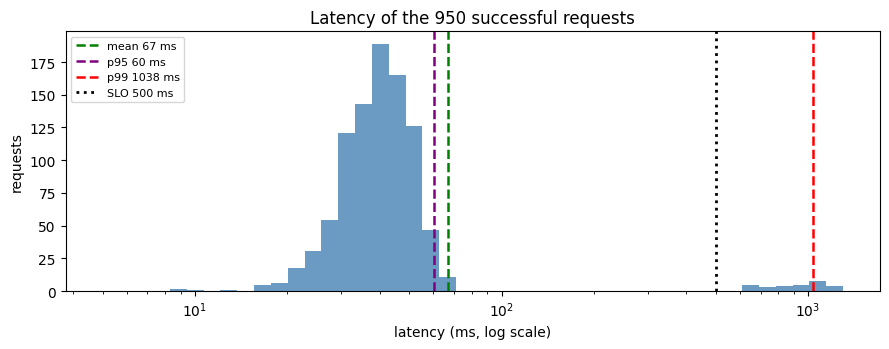

requests over the 500 ms SLO: 29 of 950 (3.1%)
mean 67.0 ms | p95 60.4 ms | p99 1037.7 ms


In [3]:
# WHAT: draw the latency distribution of every successful request, marking
# mean, p95, p99 and the 500 ms SLO.
# WHY: an alert threshold is a line drawn on this picture. Which line you pick
# decides whether you page someone for the typical request or the worst one.
import matplotlib.pyplot as plt

ok_latencies = np.array([r["latency_ms"] for r in logs if not r["error"]])
mean_lat = float(ok_latencies.mean())
p95_lat = float(np.percentile(ok_latencies, 95))
p99_lat = float(np.percentile(ok_latencies, 99))

fig, ax = plt.subplots(figsize=(9, 3.6))
# Log-spaced bins: the fast bulk and the slow tail are two orders of magnitude apart.
ax.hist(ok_latencies, bins=np.logspace(np.log10(5), np.log10(1300), 45),
        color="steelblue", alpha=0.8)
ax.set_xscale("log")
for value, colour, label in [(mean_lat, "green",  f"mean {mean_lat:.0f} ms"),
                             (p95_lat,  "purple", f"p95 {p95_lat:.0f} ms"),
                             (p99_lat,  "red",    f"p99 {p99_lat:.0f} ms")]:
    ax.axvline(value, color=colour, linestyle="--", linewidth=1.8, label=label)
ax.axvline(500, color="black", linestyle=":", linewidth=2, label="SLO 500 ms")
ax.set_xlabel("latency (ms, log scale)")
ax.set_ylabel("requests")
ax.set_title(f"Latency of the {len(ok_latencies)} successful requests")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("/tmp/alerting_latency_distribution.png", dpi=72)
plt.show()

n_slow = int((ok_latencies > 500).sum())
print(f"requests over the 500 ms SLO: {n_slow} of {len(ok_latencies)} "
      f"({n_slow / len(ok_latencies):.1%})")
print(f"mean {mean_lat:.1f} ms | p95 {p95_lat:.1f} ms | p99 {p99_lat:.1f} ms")

**Read the figure.** The distribution has two islands: a bulk around 40 ms where almost every request lives, and a small cluster near 600-1200 ms — the 29 injected slow requests, about 3% of traffic. The mean (green) lands at **67 ms**, in the empty gap between them: *no request was actually served in 67 ms*. Note where it sits relative to the purple line — the mean is **above the p95**, because three percent of requests are 15-30x slower than typical and that is enough to drag an average past the 95th percentile.

**What it proves.** A single average cannot describe a bimodal latency distribution, and a threshold on the mean would be a threshold on a number that describes nobody. Only the p99 (red, ~1038 ms) reaches the slow island and crosses the 500 ms SLO — which is exactly the alert the manager fires in Section 4. This is also why `check_latency` uses a percentile and not a mean.

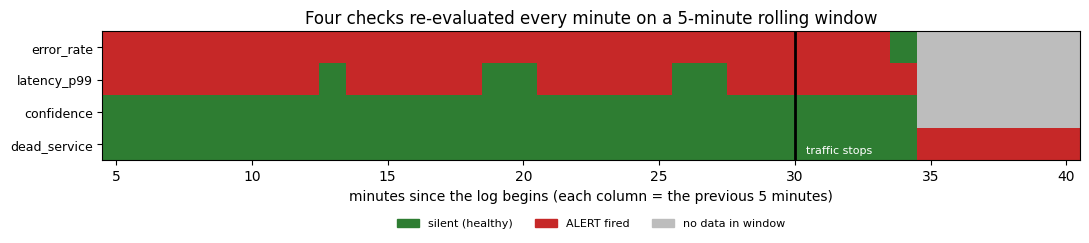

error_rate     fired in 29/36 windows, blind (no data) in  6
latency_p99    fired in 25/36 windows, blind (no data) in  6
confidence     fired in  0/36 windows, blind (no data) in  6
dead_service   fired in  6/36 windows, blind (no data) in  0

Traffic stops at minute 30; dead_service first fires at minute 35 -> 5 minutes of silence before anyone is paged.


In [4]:
# WHAT: slide a 5-minute window across the log — and 10 minutes past its end —
# re-running all four checks at every minute, then draw the verdicts as a strip.
# WHY: alerts are not evaluated once. This is what the on-call dashboard shows:
# which check is firing, and when it changed state.
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

WINDOW_MIN = 5.0
log_start = now - timedelta(minutes=30)          # the log spans 30 minutes
minutes_axis = list(range(5, 41))                # evaluate up to 10 min past the end
check_names = ["error_rate", "latency_p99", "confidence", "dead_service"]

# 0 = silent (healthy), 1 = alert fired, 2 = no data in the window
verdicts = np.zeros((4, len(minutes_axis)))
for col, minute in enumerate(minutes_axis):
    t_now = log_start + timedelta(minutes=minute)
    window = [r for r in logs
              if log_start + timedelta(minutes=minute - WINDOW_MIN)
              <= datetime.fromisoformat(r["timestamp"]) <= t_now]
    results = [manager.check_error_rate(window),
               manager.check_latency(window),
               manager.check_confidence(window),
               manager.check_service_alive(window, now=t_now)]
    for row, result in enumerate(results):
        if row < 3 and not window:
            verdicts[row, col] = 2               # the metric checks go blind
        else:
            verdicts[row, col] = 1 if result else 0

fig, ax = plt.subplots(figsize=(11, 2.9))
ax.imshow(verdicts, aspect="auto", vmin=0, vmax=2,
          cmap=ListedColormap(["#2e7d32", "#c62828", "#bdbdbd"]),
          extent=[minutes_axis[0] - 0.5, minutes_axis[-1] + 0.5, 3.5, -0.5])
ax.set_yticks(range(4)); ax.set_yticklabels(check_names, fontsize=9)
ax.set_xlabel("minutes since the log begins (each column = the previous 5 minutes)")
ax.axvline(30, color="black", linewidth=2)
ax.text(30.4, 3.3, "traffic stops", fontsize=8, color="white")
ax.set_title("Four checks re-evaluated every minute on a 5-minute rolling window")
ax.legend(handles=[mpatches.Patch(color="#2e7d32", label="silent (healthy)"),
                   mpatches.Patch(color="#c62828", label="ALERT fired"),
                   mpatches.Patch(color="#bdbdbd", label="no data in window")],
          loc="upper center", bbox_to_anchor=(0.5, -0.38), ncol=3, fontsize=8, frameon=False)
plt.tight_layout()
plt.savefig("/tmp/alerting_rolling_verdicts.png", dpi=72)
plt.show()

for row, name in enumerate(check_names):
    fired = int((verdicts[row] == 1).sum())
    blind = int((verdicts[row] == 2).sum())
    print(f"{name:<14} fired in {fired:>2}/{len(minutes_axis)} windows, "
          f"blind (no data) in {blind:>2}")
first_dead = next((m for m, v in zip(minutes_axis, verdicts[3]) if v == 1), None)
print(f"\nTraffic stops at minute 30; dead_service first fires at minute {first_dead} "
      f"-> {first_dead - 30:.0f} minutes of silence before anyone is paged.")

**Read the strip.** Each column is one evaluation; each row is one check. `error_rate` fires in 29 of the 36 windows and `latency_p99` in 25, because the 50 errors and 30 slow requests were injected *uniformly* across the whole log — nearly every window contains its share. The few green columns are simply five-minute stretches that happened to catch no injected fault; they are luck, not recovery. `confidence` is green throughout: mean confidence stays around 0.85, far above the 0.6 threshold, so that check never fires at all in this incident.

Now look right of the black line. Traffic stops at minute 30. The three metric checks turn **grey**, not red: with no requests in the window there is nothing to compute, so `check_error_rate`, `check_latency` and `check_confidence` all return `None` — silence that a dashboard renders identically to health. Only `dead_service` goes red, and it does so at minute **35**, five minutes after the last request, because the liveness window is five minutes long.

**What it proves.** Two things this notebook argues in prose are visible here as colour. First, **an alert that is red in every window is not information** — it cannot tell you when anything changed, and it is the kind of alert an on-call engineer mutes. Second, **a dead service is invisible to metric checks by construction**: that grey band is the Robinhood shape, a service producing no errors and no slow responses because it is producing nothing. The separate liveness check is the only row that notices, and its window length is the price you pay in detection delay.

## Section 4 — Run the AlertManager

Three demonstrations:
1. **Full faulty log** — the injected errors and slow requests must fire alerts.
2. **Clean historical slice** — healthy logs must fire *nothing*, even though they are 15-30 minutes old (the liveness window anchors to the newest timestamp in the slice).
3. **Dead service** — the same old slice evaluated against the *live clock* simulates a service that stopped answering 15 minutes ago, firing the `dead_service` alert on purpose.

In [5]:
# Contrast demo: the full faulty log should fire alerts; a clean slice should not.
print("=" * 60)
print("Running AlertManager on full log (1000 requests)...")
print("=" * 60)

alerts = manager.run_all_checks(logs)

if alerts:
    print(f"\n{len(alerts)} alert(s) fired:\n")
    for a in alerts:
        print(f"  {a}")
else:
    print("\nNo alerts. All metrics within thresholds.")

print()

# Build a clean comparison slice: first 500 requests, errors and injected
# slow requests removed — this is what a healthy service's logs look like
clean_logs = [r for r in logs[:500] if not r["error"]]
for r in clean_logs:
    if r["latency_ms"] > 500:
        r["latency_ms"] = float(rng.normal(40, 10))

# The clean slice is 15-30 minutes OLD. run_all_checks anchors the liveness
# window to the newest timestamp IN the slice, so healthy-but-historical logs
# do not trip the dead-service alarm.
print("Running AlertManager on clean first 500 requests...")
clean_alerts = manager.run_all_checks(clean_logs)
if clean_alerts:
    for a in clean_alerts:
        print(f"  {a}")
else:
    print("  No alerts on clean data (as expected).")

print()

# Now fire the dead-service alert ON PURPOSE: evaluate the same old slice
# against the LIVE wall clock. The newest entry in it is ~15 minutes old, so
# from "right now" the service looks like it stopped answering — exactly the
# situation this check exists to catch.
print("Evaluating the same old slice against the live clock (service stopped 15 min ago):")
stalled_alert = manager.check_service_alive(clean_logs, now=datetime.now(timezone.utc))
print(f"  {stalled_alert}")


Running AlertManager on full log (1000 requests)...

2 alert(s) fired:

  ALERT [error_rate]: 5.00% > threshold 1.00% (50/1000 errors)
  ALERT [latency_p99]: 1037.7ms > threshold 500.0ms

Running AlertManager on clean first 500 requests...
  No alerts on clean data (as expected).

Evaluating the same old slice against the live clock (service stopped 15 min ago):
  ALERT [dead_service]: No successful predictions in last 5 minutes.


## 💬 Discuss

The AlertManager produced three distinct results worth comparing: on the full log it fired **`error_rate: 5.00% > 1.00%`** and **`latency_p99: 1037.7ms > 500.0ms`**; on the clean first 500 requests it fired **nothing**, even though those records were 15–30 minutes old; and evaluated against the live clock, the same old slice fired **`dead_service`**. Same data, three verdicts, depending entirely on what "now" means.

1. The liveness check anchors to the newest timestamp in the slice for the historical evaluation, and to the wall clock for the live one. Which is correct, and when? Describe a real situation where anchoring to the data's own timestamps would hide a genuine outage.
2. Four thresholds are hardcoded: 1% errors, 500 ms p99, 0.6 confidence, 5 minutes of silence. Pick the one you would be least comfortable defending and say what you would need to measure to replace the guess with a number.
3. Meta's engineers could not use their own tools during the outage. Read the four runbooks in section 5 and mark every step that would fail if the thing that broke were the Kubernetes control plane, or the logging pipeline itself. What would you add so the runbook survives its own subject?

## Section 5 — Incident Response Runbook

When an alert fires, follow a structured runbook. These are the standard first-response steps:

### High Latency Alert
1. Check model size — did a new, larger model get deployed?
2. Check batch size — is the service receiving more concurrent requests than expected?
3. Check hardware utilization — is the GPU/CPU saturated?
4. Check for data preprocessing bottlenecks before the model call.

### High Error Rate Alert
1. Pull the last 10 error logs — what exception is being raised?
2. Check input validation — are clients sending malformed payloads?
3. If the error started after a deployment: roll back the model artifact.
4. If the error is in a dependency (database, feature store): escalate to infrastructure team.

### Confidence Drop Alert
1. Run drift detection on the last N hours of input features (see notebook 04).
2. If drift is confirmed: trigger retraining pipeline (see notebook 02).
3. If no drift detected: check for data pipeline issues (wrong feature values being sent).

### Dead Service Alert
1. Hit the `/health` endpoint directly — does it respond?
2. In Kubernetes: `kubectl get pods -n ml-serving` — is the pod running?
3. Check pod logs: `kubectl logs <pod-name> -n ml-serving --tail=100`
4. If pod is crash-looping: describe the pod for the OOMKilled / error reason.

## Section 6 — Simulated Webhook Notification

In [6]:
# WHAT: format the fired alerts as a Slack-style webhook payload (simulated send).
# WHY: an alert nobody sees is a log line — webhooks are how checks become
# pages; the payload shape here is real Slack API format.
import json
from typing import List


def send_webhook_alert(alerts: List[str], webhook_url: str = "https://hooks.slack.com/...") -> None:
    """
    In production: POST to a Slack webhook or PagerDuty API.
    Here we simulate the payload that would be sent.
    """
    payload = {
        "text": "*ML Model Alert*",
        "attachments": [
            {
                "color": "danger",
                "fields": [
                    {"title": f"Alert {i+1}", "value": alert, "short": False}
                    for i, alert in enumerate(alerts)
                ],
            }
        ],
    }
    # In production: requests.post(webhook_url, json=payload)
    print(f"[SIMULATED] POST to {webhook_url}")
    print(json.dumps(payload, indent=2))


# Only send when something actually fired — silence is a feature, not a bug.
if alerts:
    send_webhook_alert(alerts)
else:
    print("No alerts to send.")

[SIMULATED] POST to https://hooks.slack.com/...
{
  "text": "*ML Model Alert*",
  "attachments": [
    {
      "color": "danger",
      "fields": [
        {
          "title": "Alert 1",
          "value": "ALERT [error_rate]: 5.00% > threshold 1.00% (50/1000 errors)",
          "short": false
        },
        {
          "title": "Alert 2",
          "value": "ALERT [latency_p99]: 1037.7ms > threshold 500.0ms",
          "short": false
        }
      ]
    }
  ]
}


## Summary

The alerting loop for production ML models:

1. **Define thresholds** for error rate, latency, confidence, and liveness
2. **Evaluate continuously** — run checks on a rolling window of recent logs
3. **Fire alerts** via Slack/PagerDuty when thresholds are breached
4. **Follow the runbook** — each alert type has a standard diagnostic sequence
5. **Act** — roll back, retrain, or escalate depending on root cause

## Self-Check (answer before scrolling back up)

1. **What is an SLO and how does it relate to your alert thresholds?**  
   An SLO (Service Level Objective) is a commitment to a performance target, such as "p99 latency < 300ms" or "error rate < 0.5%". Alert thresholds should be set slightly inside the SLO so that you get warned before you actually breach your commitment to users.

2. **What is the first thing you check when error rate spikes?**  
   Read the actual error messages from the last N failed requests. The exception type tells you immediately whether this is a client-side problem (bad input), a model-side problem (inference crash), or an infrastructure problem (database timeout).

3. **Why do you need a 'service alive' check separate from a latency check?**  
   If the service crashes completely, it produces zero requests — so latency metrics simply stop updating. You cannot distinguish "the service is healthy and idle" from "the service is down" using latency alone. A liveness check explicitly detects the absence of traffic.

## ⚠️ Where this breaks

- **Alerts that fire too often stop being alerts.** Four independent checks on a rolling window will produce false positives during deploys, batch jobs, and traffic troughs. Every ignored page trains the on-call engineer to ignore the next one. Alerting quality is measured by *precision*, not coverage — and an alert with no owner and no documented action should be deleted, not tuned.
- **These checks describe the service, not the model.** Error rate, latency and liveness would all have been perfectly green during Instacart's March 2020 availability collapse (Unit 3, notebook 06) and during Zillow's pricing failure. `confidence < 0.6` is the only model-quality signal here, and this course has repeatedly shown confidence to be a weak one.
- **A confidence threshold assumes a calibrated model.** 0.6 means something different for a two-class forest, a ten-class softmax and a logistic regression. Set it from your own model's observed healthy distribution, or it is a number with no units.
- **The assumption that must hold:** the alerting path is independent of the thing it watches. Meta's was not. If your alert reads the same log pipeline, runs in the same cluster, and pages through the same network as the service, then a large enough failure takes out the alarm along with the building. External synthetic checks — an independent prober calling `/health` from outside — are the cheap insurance.
- **The webhook here is simulated, and delivery is where alerting actually fails.** Real paging involves rate limits, deduplication, escalation policies, on-call rotations and time zones. A perfect detection that pages a Slack channel nobody watches at 03:00 has detected nothing.
- **The cheaper alternative.** For an internal model with a human in the loop, a daily summary email and a single "is it up" synthetic check will catch nearly everything a four-alert manager would, at a fraction of the tuning cost. Build real alerting when someone is genuinely on call and the minutes matter.

## 📚 References

1. Sculley, D., Holt, G., Golovin, D., et al. (2015). *Hidden Technical Debt in Machine Learning Systems*. NeurIPS 28. <https://papers.nips.cc/paper_files/paper/2015/hash/86df7dcfd896fcaf2674f757a2463eba-Abstract.html>
2. Breck, E., Cai, S., Nielsen, E., Salib, M., & Sculley, D. (2017). *The ML Test Score: A Rubric for ML Production Readiness and Technical Debt Reduction*. IEEE Big Data. <https://research.google/pubs/the-ml-test-score-a-rubric-for-ml-production-readiness-and-technical-debt-reduction/>
3. Shankar, S., Garcia, R., Hellerstein, J. M., & Parameswaran, A. G. (2022). *Operationalizing Machine Learning: An Interview Study*. arXiv. <https://arxiv.org/abs/2209.09125>
4. Vinay, V. (2025). *Failure Modes in LLM Systems: A System-Level Taxonomy for Reliable AI Applications*. arXiv:2511.19933. <https://arxiv.org/abs/2511.19933>
5. Solomon, R., Yerushalmi Levi, Y., Vaknin, L., et al. (2025). *LumiMAS: A Comprehensive Framework for Real-Time Monitoring and Enhanced Observability in Multi-Agent Systems*. arXiv:2508.12412. <https://arxiv.org/abs/2508.12412>
